### **Customer Segmentation**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

## **DATA PRE-PROCESSING**

In [3]:

# Importing CSV file
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
# Dataset Shape
print(df.shape)

# Dataset Information
df.info()

# Statistical Summary
df.describe()

(200, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,1.400000
std,57.879185,13.969007,26.264721,25.823522,1.449311
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,3.000000
max,200.000000,70.000000,137.000000,99.000000,4.000000


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


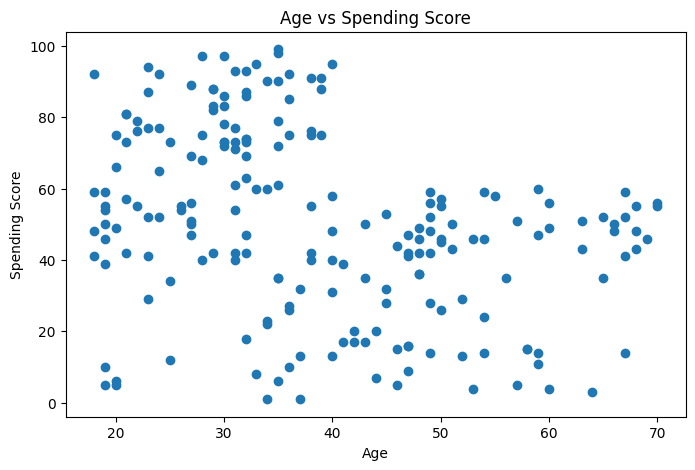

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Age"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")

plt.show()

This code creates a simple scatter plot to visualize the relationship between Age and Spending Score using Matplotlib.

In human language, it does this:

First, it sets the size of the graph to make it 8 inches wide and 5 inches tall.
Then, it plots individual data points where:
The X-axis represents customers’ ages (df["Age"])
The Y-axis represents their spending scores (df["Spending Score (1-100)"])
Each point on the graph shows one customer’s age and how much they tend to spend.
It labels the X-axis as "Age" and the Y-axis as "Spending Score" so the graph is easy to understand.
It gives the plot a title: "Age vs Spending Score"
Finally, it displays the graph on the screen.

In [17]:
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

This selects two columns from the dataset—Annual Income and Spending Score—and stores them in a new variable X.

In [8]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


X.head() shows the first 5 rows of the dataset X.

In [9]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

It creates an empty list called wcss to store values.
Then it runs a loop from 1 to 10, trying different numbers of clusters for K-Means.
For each value of i:
It builds a KMeans clustering model with i clusters.
It fits the model on the data X.
It calculates how well the clustering fits using WCSS (Within-Cluster Sum of Squares).
It stores that WCSS value in the list.

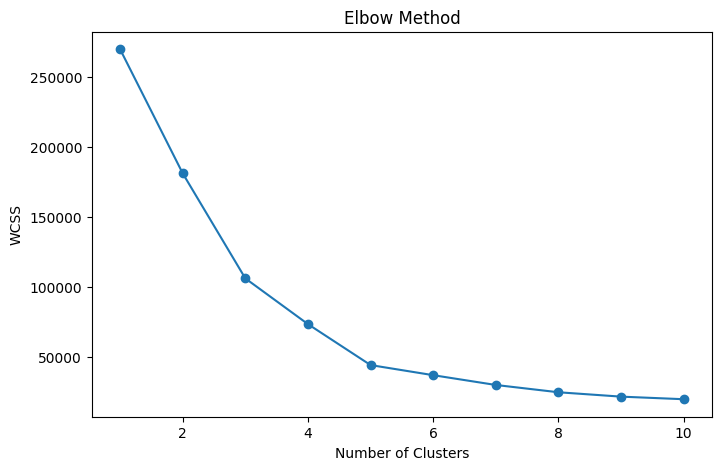

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

This draws the Elbow Method graph.

It sets the figure size to 8×5 inches.
It plots number of clusters (1 to 10) on the X-axis and WCSS values on the Y-axis.
Each point is marked with a circle (marker='o').
It adds title and axis labels for clarity.

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

df["Cluster"] = y_kmeans

This applies K-Means clustering to the data.

It creates a KMeans model with 5 clusters.
It fits the model on X and assigns each data point to a cluster.
The cluster labels are stored in y_kmeans.
Finally, it adds a new column "Cluster" to the dataset df showing which cluster each row belongs to.

In [12]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


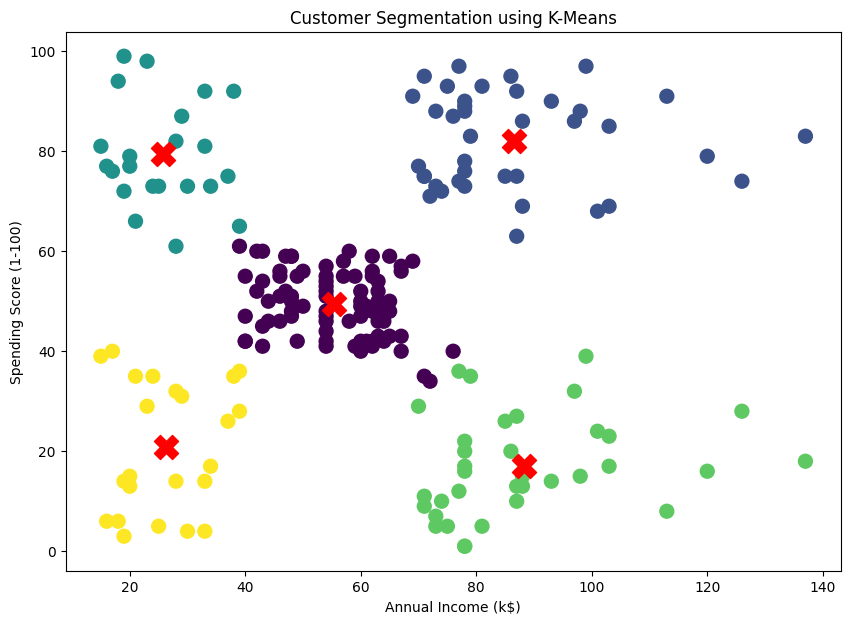

In [13]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap="viridis",
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c="red",
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

This  shows the clustered data in a graph. Each point is colored based on its cluster group. The red “X” marks show the center of each cluster. This helps us easily understand how the data is divided into different customer groups.

In [14]:
plt.savefig(
    "customer_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

This saves the current plot as an image file named “customer_segmentation.png”.
It saves it in high quality (300 DPI) and removes extra empty spaces around the graph for a clean output.

In [15]:
from google.colab import files

files.download(
    "customer_segmentation.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This code is used in Google Colab to download the saved image file.